# ARTI406 – Assignment 1: Exploratory Data Analysis
## Dataset: LEGO Sets Dataset
**Source:** Kaggle – [LEGO Sets Dataset](https://www.kaggle.com/datasets/mterzolo/lego-sets)

**Student:** Farah Alghamdi

---

## 1. Introduction

This notebook presents an Exploratory Data Analysis (EDA) of the **LEGO Sets Dataset**. The dataset contains information about LEGO product sets sold across 21 countries, including pricing, piece count, theme, age group, difficulty rating, and customer reviews. It has 12,261 rows and 14 columns.

The goal is to understand LEGO's product catalog: which themes are most popular, how price relates to piece count, and what the review patterns look like.

## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
print('Libraries loaded.')

Libraries loaded.


## 3. Load the Dataset

In [ ]:
df_raw = pd.read_csv('lego_sets.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (12261, 14)


,ages,list_price,num_reviews,piece_count,play_star_rating,prod_desc,prod_id,prod_long_desc,review_difficulty,set_name,star_rating,theme_name,val_star_rating,country
0,6-12,29.99,2.0,277.0,4.0,Catapult into action and take back the eggs fr...,75823.0,Use the staircase catapult to launch Red into ...,Average,Bird Island Egg Heist,4.5,Angry Birds™,4.0,US
1,6-12,19.99,2.0,168.0,4.0,Launch a flying attack and rescue the eggs fro...,75822.0,Pilot Pig has taken off from Bird Island with ...,Easy,Piggy Plane Attack,5.0,Angry Birds™,4.0,US
2,6-12,12.99,11.0,74.0,4.3,Chase the piggy with lightning-fast Chuck and ...,75821.0,Pitch speedy bird Chuck against the Piggy Car....,Easy,Piggy Car Escape,4.3,Angry Birds™,4.1,US
3,12+,99.99,23.0,1032.0,3.6,Explore the architecture of the United States ...,21030.0,Discover the architectural secrets of the icon...,Average,United States Capitol Building,4.6,Architecture,4.3,US
4,12+,79.99,14.0,744.0,3.2,Recreate the Solomon R. Guggenheim Museum® wit...,21035.0,Discover the architectural secrets of Frank Ll...,Challenging,Solomon R. Guggenheim Museum®,4.6,Architecture,4.1,US


In [ ]:
print('Column types:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())
print('\nDuplicate rows:', df_raw.duplicated().sum())

Column types:
ages                  object
list_price           float64
num_reviews          float64
piece_count          float64
play_star_rating     float64
prod_desc             object
prod_id              float64
prod_long_desc        object
review_difficulty     object
set_name              object
star_rating          float64
theme_name            object
val_star_rating      float64
country               object
dtype: object

Missing values:
ages                    0
list_price              0
num_reviews          1620
piece_count             0
play_star_rating     1775
prod_desc             377
prod_id                 0
prod_long_desc          0
review_difficulty    2055
set_name                0
star_rating          1620
theme_name              3
val_star_rating      1795
country                 0
dtype: int64



Duplicate rows: 1389


## 4. Data Cleaning

### Why Cleaning Was Needed

| Issue | Column(s) | Action |
|---|---|---|
| **1,389 duplicate rows** | All | Removed with `drop_duplicates()` |
| **Missing values** | num_reviews, star_rating, play_star_rating, val_star_rating, review_difficulty, prod_desc, theme_name | Dropped rows with missing key columns; filled others with median/mode |
| **Inconsistent age format** | ages | Kept as-is (categorical label) |

### Step 1 – Remove Duplicate Rows

In [ ]:
print('Rows BEFORE removing duplicates:', len(df_raw))
df = df_raw.drop_duplicates()
print('Rows AFTER removing duplicates:', len(df))

Rows BEFORE removing duplicates: 12261
Rows AFTER removing duplicates: 10872


### Step 2 – Drop Rows with Missing Critical Values

In [ ]:
# Drop rows missing theme_name (only 3 rows)
df = df.dropna(subset=['theme_name'])
print('Rows after dropping missing theme_name:', len(df))

# Fill missing review columns with median
for col in ['num_reviews', 'star_rating', 'play_star_rating', 'val_star_rating']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'Filled {col} missing values with median: {median_val:.2f}')

# Fill review_difficulty with mode
mode_val = df['review_difficulty'].mode()[0]
df['review_difficulty'] = df['review_difficulty'].fillna(mode_val)
print(f'Filled review_difficulty missing values with mode: {mode_val}')

Rows after dropping missing theme_name: 10869
Filled num_reviews missing values with median: 6.00
Filled star_rating missing values with median: 4.60
Filled play_star_rating missing values with median: 4.50
Filled val_star_rating missing values with median: 4.30
Filled review_difficulty missing values with mode: Easy


### Cleaned Dataset Summary

In [ ]:
print('Final cleaned shape:', df.shape)
print('\nRemaining missing values:')
print(df[['ages','list_price','num_reviews','piece_count','star_rating',
          'theme_name','review_difficulty','country']].isnull().sum())
df[['list_price','piece_count','num_reviews','star_rating']].describe().round(2)

Final cleaned shape: (10869, 14)

Remaining missing values:
ages                 0
list_price           0
num_reviews          0
piece_count          0
star_rating          0
theme_name           0
review_difficulty    0
country              0
dtype: int64


,list_price,piece_count,num_reviews,star_rating
count,10869.00,10869.00,10869.00,10869.00
mean,67.31,503.94,16.30,4.52
std,94.67,831.25,35.81,0.48
min,2.27,1.00,1.00,1.80
25%,21.90,97.00,3.00,4.30
50%,36.59,223.00,6.00,4.60
75%,73.19,556.00,12.00,4.90
max,1104.87,7541.00,367.00,5.00


## 5. Visualizations and Insights

Seven visualizations are presented below to explore the LEGO dataset from different angles.

### Plot 1 – Top 10 LEGO Themes by Number of Sets (Bar Chart)

**Why chosen:** A bar chart clearly shows which themes have the most product sets in the catalog.

**Insight:** Star Wars is by far the most represented theme, followed by DUPLO and City. This reflects LEGO's heavy investment in licensed and classic themes.

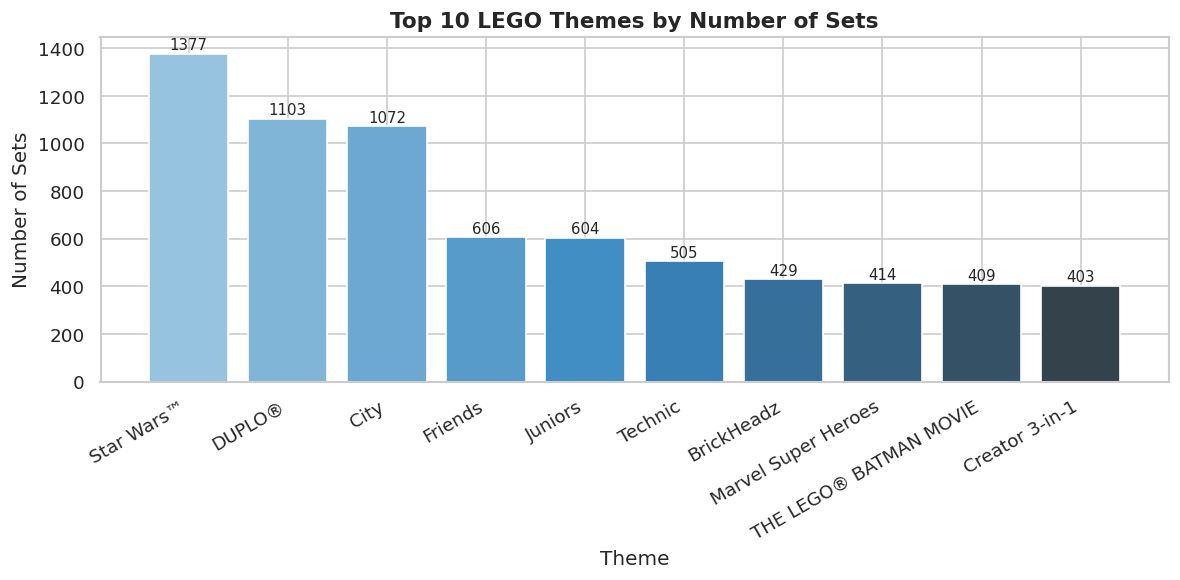

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
top_themes = df['theme_name'].value_counts().head(10)
bars = ax.bar(top_themes.index, top_themes.values,
              color=sns.color_palette('Blues_d', 10))
ax.set_title('Top 10 LEGO Themes by Number of Sets', fontweight='bold')
ax.set_xlabel('Theme')
ax.set_ylabel('Number of Sets')
plt.xticks(rotation=30, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 2 – Distribution of LEGO Set Prices (Histogram)

**Why chosen:** A histogram shows how prices are distributed across all sets, revealing whether most sets are affordable or expensive.

**Insight:** The majority of LEGO sets are priced under \$50, with the distribution heavily right-skewed. A small number of premium sets cost over \$200, pulling the mean higher than the median.

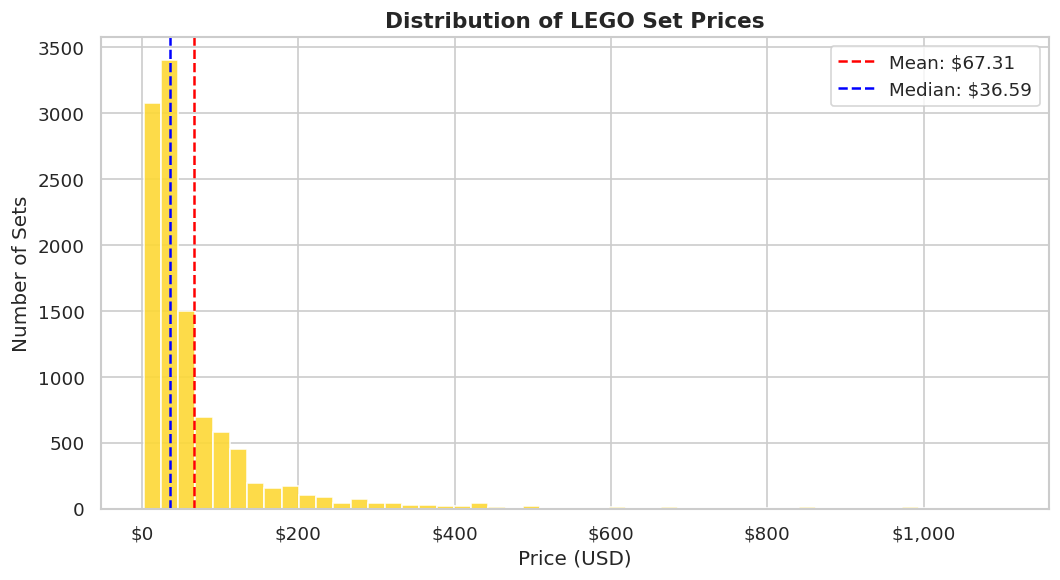

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['list_price'], bins=50, color='#FDD835', edgecolor='white', alpha=0.9)
ax.axvline(df['list_price'].mean(),   color='red',    linestyle='--', linewidth=1.5,
           label=f"Mean: ${df['list_price'].mean():.2f}")
ax.axvline(df['list_price'].median(), color='blue',   linestyle='--', linewidth=1.5,
           label=f"Median: ${df['list_price'].median():.2f}")
ax.set_title('Distribution of LEGO Set Prices', fontweight='bold')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Number of Sets')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### Plot 3 – Piece Count vs Price (Scatter Plot)

**Why chosen:** A scatter plot reveals whether there is a relationship between how many pieces a set has and how much it costs.

**Insight:** There is a clear positive relationship — sets with more pieces cost more. However, there is significant spread, meaning some sets are priced higher than their piece count alone would suggest.

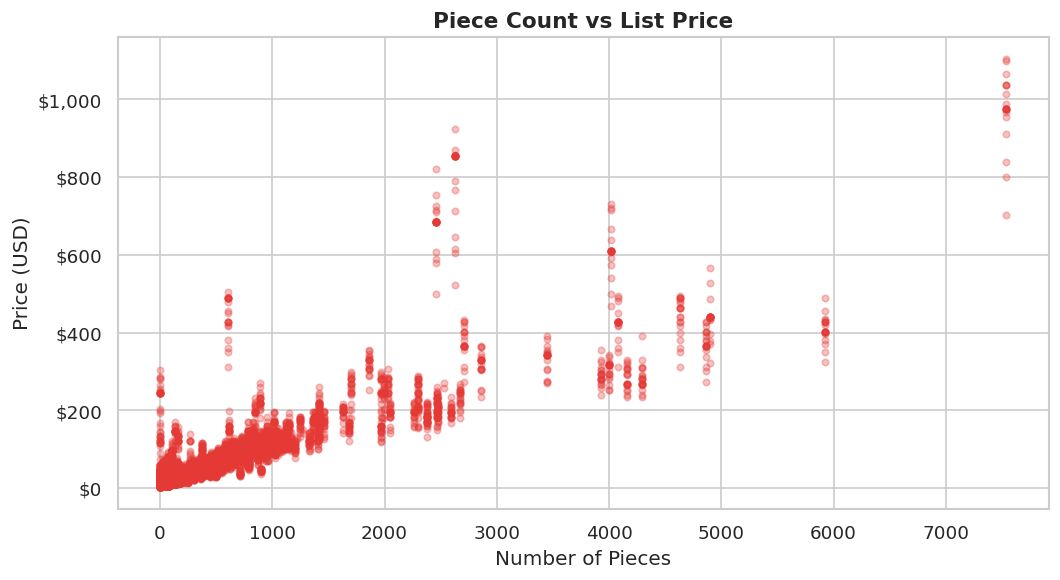

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['piece_count'], df['list_price'],
           alpha=0.3, s=15, color='#E53935')
ax.set_title('Piece Count vs List Price', fontweight='bold')
ax.set_xlabel('Number of Pieces')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Plot 4 – Sets by Review Difficulty (Pie Chart)

**Why chosen:** A pie chart shows the proportional breakdown of difficulty levels across all sets.

**Insight:** The majority of LEGO sets are rated 'Easy' or 'Average' in difficulty, confirming that LEGO targets a broad audience including younger children. Very Challenging sets make up less than 1% of the catalog.

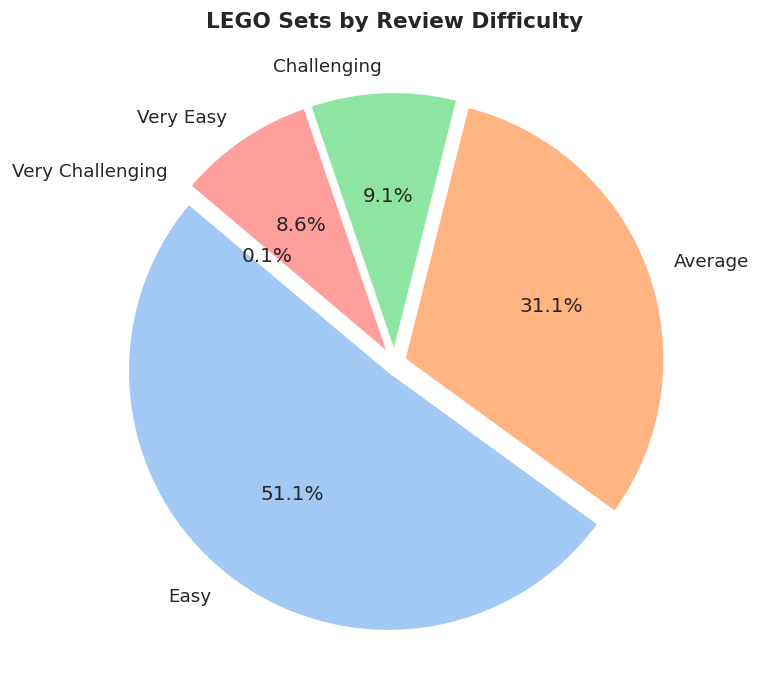

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
diff_counts = df['review_difficulty'].value_counts()
ax.pie(diff_counts.values, labels=diff_counts.index,
       autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('pastel'),
       explode=[0.04]*len(diff_counts),
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('LEGO Sets by Review Difficulty', fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 5 – Average Price by Review Difficulty (Bar Chart)

**Why chosen:** This bar chart connects difficulty level to price, testing whether harder sets cost more.

**Insight:** As expected, more challenging sets have a significantly higher average price. 'Very Challenging' sets average well over \$200, while 'Very Easy' sets average around \$20.

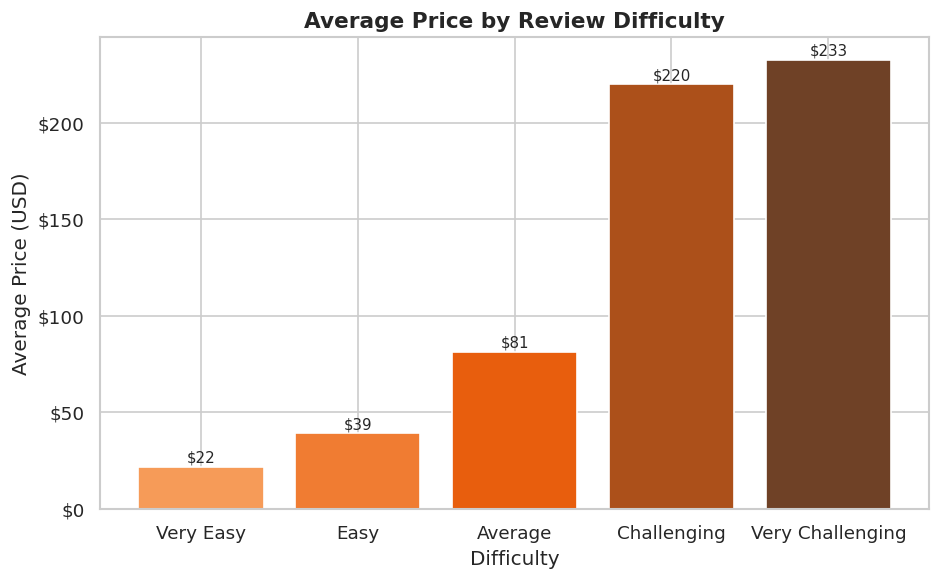

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ['Very Easy','Easy','Average','Challenging','Very Challenging']
avg_price = df.groupby('review_difficulty')['list_price'].mean().reindex(order)
bars = ax.bar(avg_price.index, avg_price.values,
              color=sns.color_palette('Oranges_d', 5))
ax.set_title('Average Price by Review Difficulty', fontweight='bold')
ax.set_xlabel('Difficulty')
ax.set_ylabel('Average Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'${bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 6 – Distribution of Star Ratings (Histogram)

**Why chosen:** A histogram of customer star ratings shows how satisfied buyers are overall.

**Insight:** Most LEGO sets receive ratings between 4.0 and 5.0, indicating very high customer satisfaction. Very few sets receive ratings below 3.0, suggesting consistent product quality.

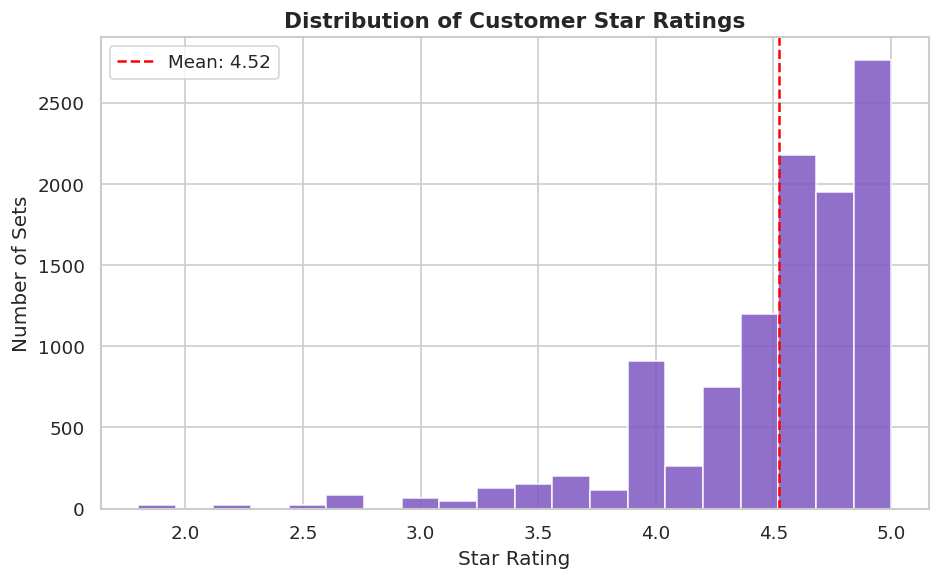

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['star_rating'], bins=20, color='#7E57C2', edgecolor='white', alpha=0.85)
ax.axvline(df['star_rating'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['star_rating'].mean():.2f}")
ax.set_title('Distribution of Customer Star Ratings', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Sets')
ax.legend()
plt.tight_layout()
plt.show()

### Plot 7 – Correlation Heatmap of Numeric Features

**Why chosen:** A heatmap gives a quick overview of how all numeric variables relate to each other.

**Insight:** Price and piece count have the strongest positive correlation (≈0.78), confirming the pattern seen in Plot 3. Star rating and number of reviews have a weak positive correlation, meaning popular sets tend to be rated slightly higher.

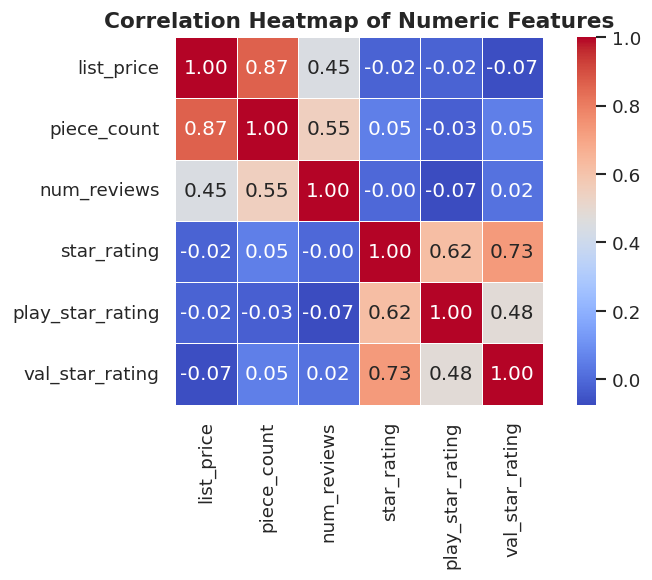

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['list_price','piece_count','num_reviews','star_rating',
           'play_star_rating','val_star_rating']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [ ]:
print('=== Dataset Summary ===')
print(f'Total Sets:          {len(df):,}')
print(f'Unique Themes:       {df["theme_name"].nunique()}')
print(f'Countries:           {df["country"].nunique()}')
print(f'Avg Price:           ${df["list_price"].mean():.2f}')
print(f'Avg Pieces per Set:  {df["piece_count"].mean():.0f}')
print(f'Avg Star Rating:     {df["star_rating"].mean():.2f}')
print(f'Most Common Theme:   {df["theme_name"].value_counts().idxmax()}')
print(f'Most Common Difficulty: {df["review_difficulty"].value_counts().idxmax()}')

=== Dataset Summary ===
Total Sets:          10,869
Unique Themes:       40
Countries:           21
Avg Price:           $67.31
Avg Pieces per Set:  504
Avg Star Rating:     4.52
Most Common Theme:   Star Wars™
Most Common Difficulty: Easy


## 7. Conclusions

This EDA of the LEGO Sets Dataset revealed the following key findings:

1. **Popular Themes:** Star Wars, DUPLO, and City dominate the LEGO catalog in terms of number of sets.

2. **Pricing:** Most sets are affordable (under \$50), but a small number of premium sets cost over \$200. Price is strongly linked to piece count.

3. **Difficulty:** The majority of sets are Easy or Average difficulty, reflecting LEGO's broad target audience.

4. **Customer Satisfaction:** Star ratings are consistently high (mostly 4–5 stars), indicating strong product quality across the catalog.

5. **Price vs Difficulty:** More challenging sets are significantly more expensive, suggesting they target adult collectors and enthusiasts.